# Global sensitivity analysis: Mass-action kinetics, double binding 

Nathaniel Linden (UCSD MAE) - March  2023

In [2]:
import numpy as np
from SALib.sample import sobol as sobol_samp
from SALib.sample import morris as morris_samp
from SALib.analyze import sobol as sobol_analyze
from SALib.analyze import morris as morris_analyze
from SALib.analyze.hdmr import analyze as hdmr_analyze
import os
import sys

import jax
import jax.numpy as jnp
from jax import lax
import equinox as eqx
import diffrax as dfrx

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy.stats import t

# load code
sys.path.insert(0, '/scratch/nlinden/AMPK/src/ampk_models/odes')
sys.path.insert(0, '/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis')
import ampk_MA_double_mech_diffrax as model
import ampk_MA_double_mech as model1
from gsa_utils import *

%matplotlib inline
plt.style.use('~/.matplotlib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True

### First, we want to plot how well the steady-state checking algorithm is working...
This uses solutions generated with the sunode solver and with $90 \%$ bounds.

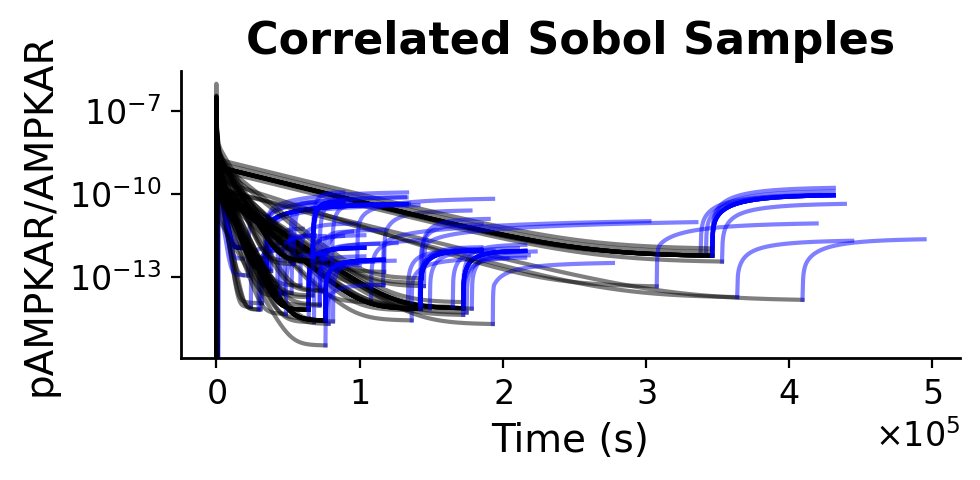

In [3]:
# params = model1.ampk_MA_double_mech_get_params()
# states = model1.ampk_MA_double_mech_get_states()
# nparams = len(params)
# nstates = len(states)

# # create sunode problem
# problem_ode = sunode.SympyProblem(
#     params=params,
#     states=states,
#     rhs_sympy=model1.ampk_MA_double_mech_RHS,
#     # specify variables to take gradients wrt
#     derivative_params=(),
# )

fig, ax = plt.subplots(1,1, figsize=(5,2.5))
sobol_sols_corr_short = np.load('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/20230412_pm_90/sols_sobol_corr_short.npy', allow_pickle=True)
    
for a in sobol_sols_corr_short:
    ax.plot(a[3], a[1]['pAMPKAR']/a[1]['AMPKAR'], 'k', alpha=0.5)
    ax.plot(1+a[3][-1]+a[4], a[2]['pAMPKAR']/a[2]['AMPKAR'], 'b', alpha=0.5)
ax.set_yscale('log')
ax.set_xlabel('Time (s)')
ax.set_ylabel('pAMPKAR/AMPKAR')
ax.set_title('Correlated Sobol Samples')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/sobol_corr_ss_check.pdf')

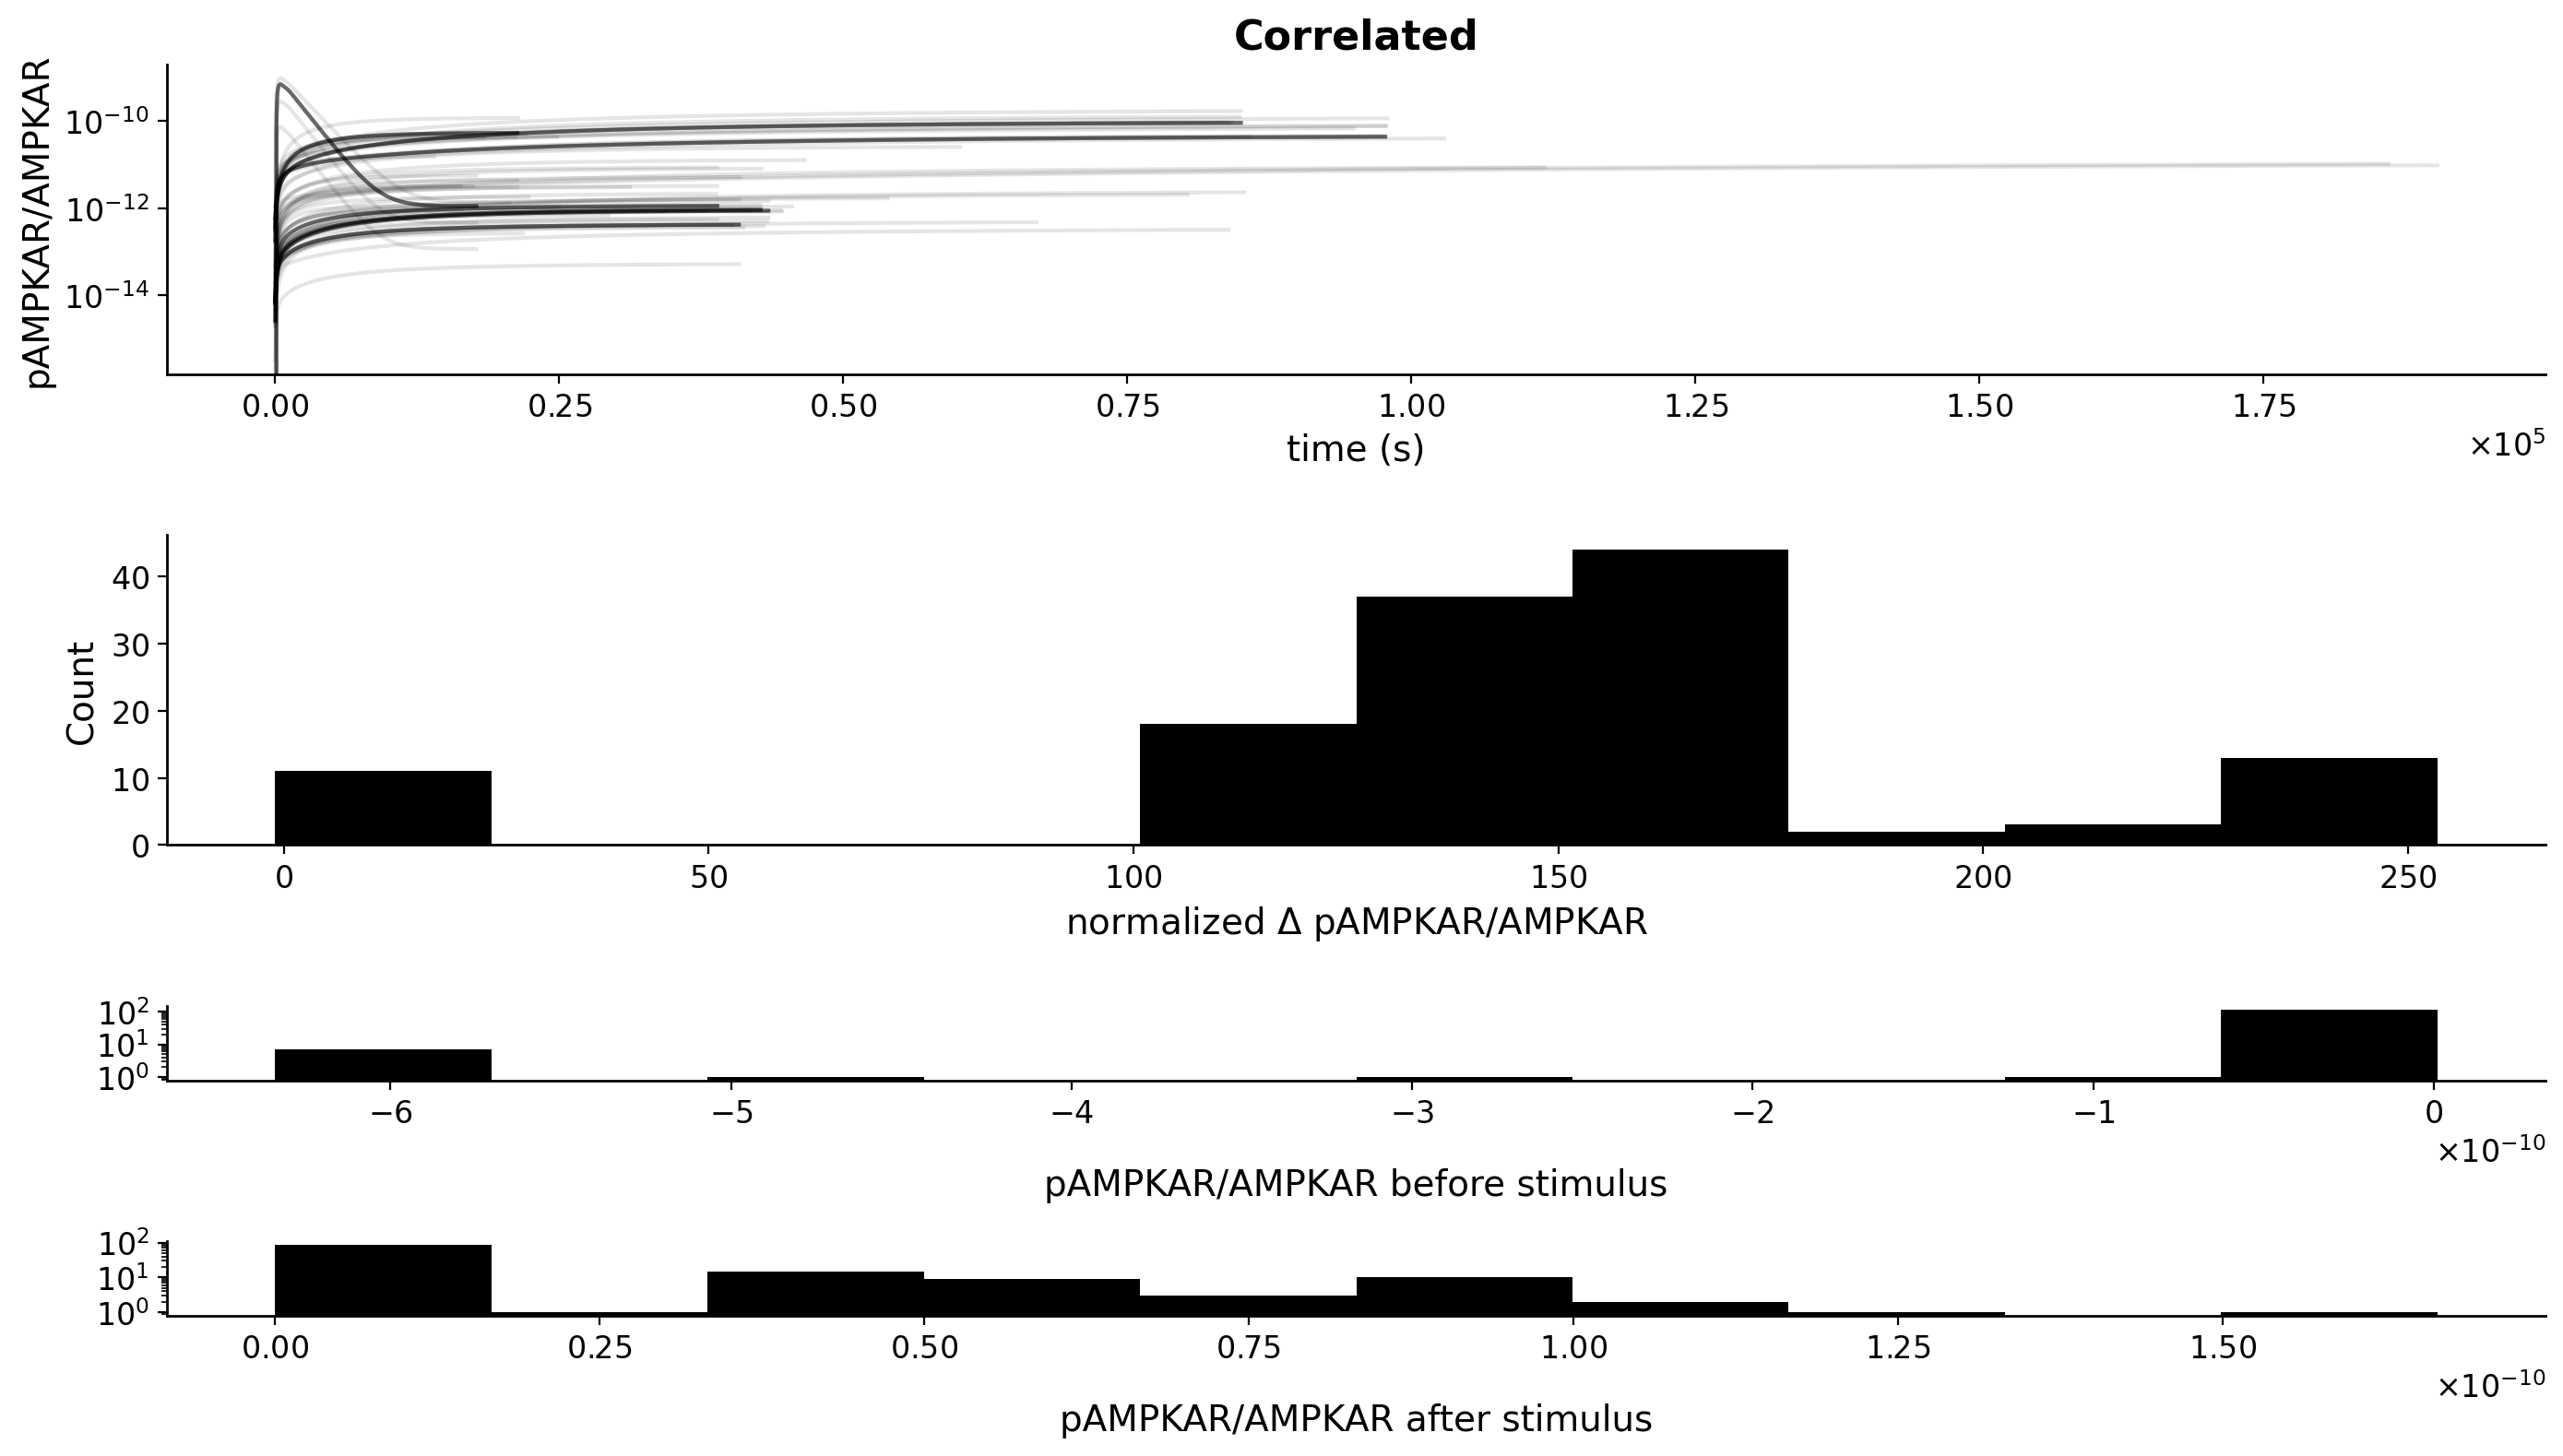

In [4]:
# if 'sobol_sols_short' in vars():
#     del sobol_sols_short
# morris_sols_corr_short = np.load('./MA_double_mech/sols_morris_corr_short.npy', allow_pickle=True)
# plot the solutions
# fig, ax = plt.subplots(3, 2, figsize=(10,10))
# f, (a0, a1) = plt.subplots(1, 2, height_ratios=[3, 1])
fig, ax = plt.subplot_mosaic(
    [['traj A'],
     ['traj A'],
     ['hist A'],
     ['hist A'],
     ['hist C'],
     ['hist E']],figsize=(14,8))
for sol in sobol_sols_corr_short:
    ax['traj A'].plot(sol[4], sol[2]['pAMPKAR']/sol[2]['AMPKAR'], color='k', alpha=0.1)
ax['hist A'].hist(np.array([sol[0][1] for sol in sobol_sols_corr_short]), color='k')
ax['hist C'].hist(np.array([sol[0][0] for sol in sobol_sols_corr_short]), color='k')
ax['hist E'].hist(np.array([sol[0][1]*sol[0][0]+sol[0][0] for sol in sobol_sols_corr_short]), color='k')



# plot formatting
ax['traj A'].set_xlabel('time (s)')
ax['traj A'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj A'].set_title('Correlated')
ax['traj A'].set_yscale('log')

ax['hist A'].set_xlabel('normalized $\Delta$ pAMPKAR/AMPKAR')
ax['hist A'].set_ylabel('Count')
# ax['hist A'].set_xlim([0.0, 200.0])

ax['hist C'].set_xlabel('pAMPKAR/AMPKAR before stimulus', labelpad=15)
ax['hist C'].set_yscale('log')

ax['hist E'].set_xlabel('pAMPKAR/AMPKAR after stimulus', labelpad=15)
ax['hist E'].set_yscale('log')

fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/bounds_test_90.pdf')

### Now load the parameter values and solutions for the sensitivity analysis
We will use the same parameter values as in the previous notebook, but we will use the solutions generated with the diffrax solver.
Additionally, we will use the $\pm 50 \%$ bounds for the sensitivity analysis.

In [5]:
# remove "short" runs 
if 'sobol_sols_corr_short' in vars():
    del sobol_sols_corr_short
if 'morris_sols_corr_short' in vars():
    del morris_sols_corr_short

# load samples
param_vals_sobol_corr = np.load('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/param_vals_sobol_MA_corr.npy')

# load solutions
sobol_sols_corr = np.load('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/sols_sobol_corr.npy')
# reshape into 2D array
sobol_sols_corr = sobol_sols_corr.reshape(sobol_sols_corr.shape[0]*sobol_sols_corr.shape[1], sobol_sols_corr.shape[2])
nsols, nqoi = sobol_sols_corr.shape

In [6]:
ss_pre = [(sol[1], idx) for sol, idx in zip(sobol_sols_corr, range(nsols))]
print('There are', nsols, 'total correlated Sobol samples.')
print(sum([ss[0] < 0.0 for ss in ss_pre]), 'of them have negative initial steady-states')

neg_idxs = []
for ss in ss_pre:
    if ss[0] <0.0:
        neg_idxs.append(ss[1])
# param_vals_sobol_corr[neg_idxs]


There are 30720 total correlated Sobol samples.
0 of them have negative initial steady-states


In [7]:
############################################
# First for Mass action parameters
nominal_vals_MA = [
   2.5e-3, # KdAMP
   1.5e-3, # KdADP
   1.7e-3, # KdATP
   90.467, # kOnCaMKK = (koff+kphos/Km)
   0.357, # kPhosCaMKK
   0.742, # kOnLKB1
   3.92e-2, # kPhosLKB1
   16.56, # kOnPP
   1.1e-1, # kDephosPP
   1569.59, # kOnAMPK
   6.33, # kPhosAMPK
   16.56, # kOnPP1
   1.1e-1, # kDephosPP1
   1e-3, # AMPKAR
]

bounds_MA = [[0.5*param, 1.5*param] for param in nominal_vals_MA]

param_names_MA = ['KdAMP', 'KdADP', 'KdATP', 'kOnCaMKK', 'kPhosCaMKK', 
               'kOnLKB1','kPhosLKB1','kOnPP','kDephosPP', 
               'kOnAMPK','kPhosAMPK', 'kOnPP1','kDephosPP1', 'AMPKAR']
state_names = ['AMP', 'ADP', 'ATP', 'AMPK', 'pAMPK', 'AMP_AMPK', 'ADP_AMPK', 
               'ATP_AMPK', 'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK', 'AMP_AMP_AMPK', 
               'AMP_ADP_AMPK', 'AMP_ATP_AMPK', 'ADP_ADP_AMPK', 'ADP_ATP_AMPK', 'ATP_ATP_AMPK', 
               'AMP_AMP_pAMPK', 'AMP_ADP_pAMPK', 'AMP_ATP_pAMPK', 'ADP_ADP_pAMPK', 'ADP_ATP_pAMPK', 
               'ATP_ATP_pAMPK', 'CaMKK', 'CaMKK_AMPK', 'CaMKK_AMP_AMPK', 'CaMKK_ADP_AMPK', 'CaMKK_ATP_AMPK', 
               'CaMKK_AMP_AMP_AMPK', 'CaMKK_AMP_ADP_AMPK', 'CaMKK_AMP_ATP_AMPK', 'CaMKK_ADP_ADP_AMPK', 'CaMKK_ADP_ATP_AMPK', 
               'CaMKK_ATP_ATP_AMPK', 'LKB1', 'LKB1_AMP_AMPK', 'LKB1_ADP_AMPK', 'LKB1_AMP_AMP_AMPK', 'LKB1_AMP_ADP_AMPK', 
               'LKB1_ADP_ADP_AMPK', 'PP', 'PP_pAMPK', 'PP_ATP_pAMPK', 'PP_AMP_ATP_pAMPK', 'PP_ADP_ATP_pAMPK', 
               'PP_ATP_ATP_pAMPK', 'AMPKAR', 'pAMPKAR', 'AMPKAR_AMP_pAMPK', 'AMPKAR_AMP_AMP_pAMPK', 
               'AMPKAR_AMP_ADP_pAMPK', 'PP1', 'PP1_pAMPKAR']

# print bounds and see diff between corr and uncorr params
for i in range(14):
    print(param_names_MA[i], '-- lb:', bounds_MA[i][0], '-- min', np.min(param_vals_sobol_corr[:,i]), '-- diff', np.min(param_vals_sobol_corr[:,i])-bounds_MA[i][0])
    print('ub:', bounds_MA[i][1], '-- max', np.max(param_vals_sobol_corr[:,i]), '-- diff', np.max(param_vals_sobol_corr[:,i])-bounds_MA[i][1])

# update bounds to correlated min/max
kon_idxs_MA = [3,5,7,9,11] # idxs to update
for idx in kon_idxs_MA:
    bounds_MA[idx][0] = np.min(param_vals_sobol_corr[:,idx])
    bounds_MA[idx][1] = np.max(param_vals_sobol_corr[:,idx])

problem = {'num_vars':14, 'names':param_names_MA, 'bounds': bounds_MA,}

KdAMP -- lb: 0.00125 -- min 0.0012503837398253382 -- diff 3.8373982533821197e-07
ub: 0.00375 -- max 0.0037481313804164527 -- diff -1.86861958354715e-06
KdADP -- lb: 0.00075 -- min 0.00075070945546031 -- diff 7.094554603099797e-07
ub: 0.0022500000000000003 -- max 0.002249364545568824 -- diff -6.354544311764146e-07
KdATP -- lb: 0.00085 -- min 0.0008501416247338056 -- diff 1.4162473380564637e-07
ub: 0.0025499999999999997 -- max 0.002549649712629616 -- diff -3.502873703836555e-07
kOnCaMKK -- lb: 45.2335 -- min 55.81230752534509 -- diff 10.578807525345091
ub: 135.7005 -- max 188.7657272025399 -- diff 53.06522720253989
kPhosCaMKK -- lb: 0.1785 -- min 0.1788331787092611 -- diff 0.0003331787092611116
ub: 0.5355 -- max 0.5354452717741951 -- diff -5.472822580487868e-05
kOnLKB1 -- lb: 0.371 -- min 0.48808649073722576 -- diff 0.11708649073722577
ub: 1.113 -- max 1.5013436325124416 -- diff 0.38834363251244164
kPhosLKB1 -- lb: 0.0196 -- min 0.01961199078261852 -- diff 1.1990782618521989e-05
ub: 0.05

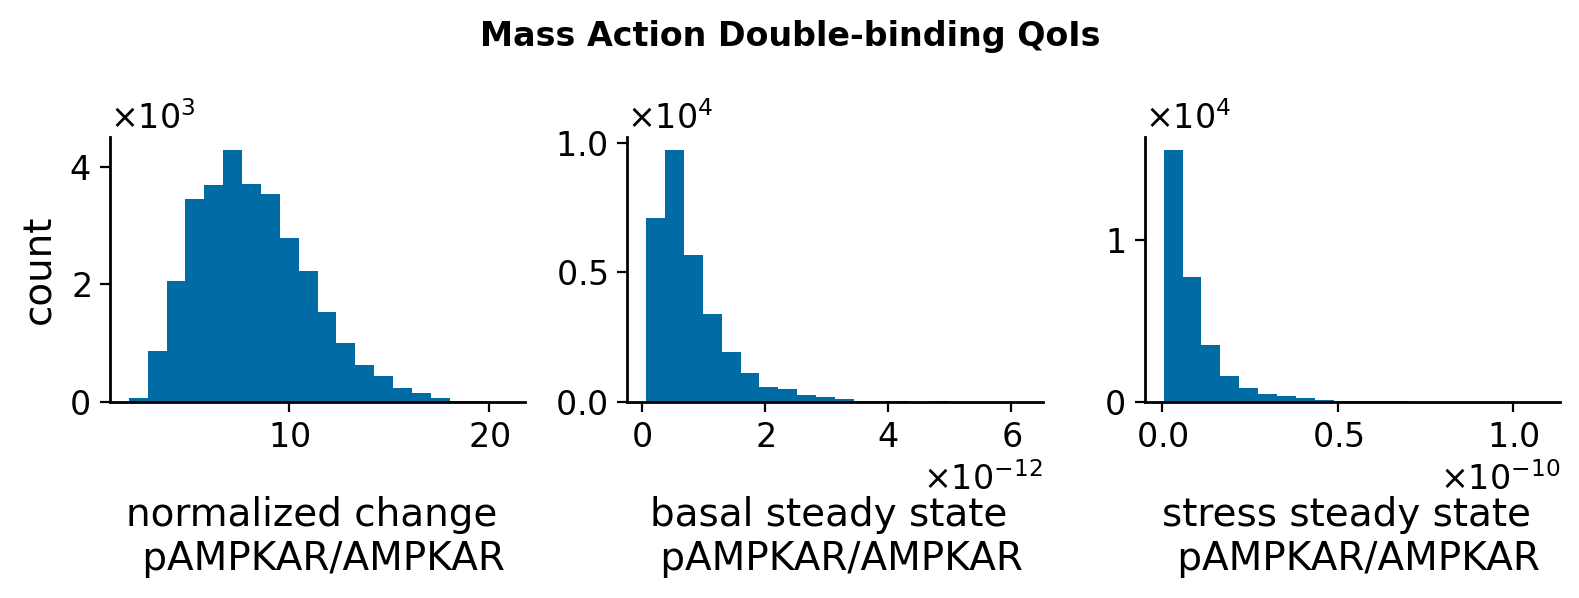

In [48]:
# histogram of output quantities of interest
fig, ax = plt.subplots(1,3, figsize=(8,3))
ax[0].hist(sobol_sols_corr[:,0], bins=20)
ax[0].set_xlabel('normalized change \n pAMPKAR/AMPKAR', labelpad=15)
ax[0].set_ylabel('count')
ax[1].hist(sobol_sols_corr[:,1], bins=20)
ax[1].set_xlabel('basal steady state \n pAMPKAR/AMPKAR', labelpad=15)
ax[2].hist(sobol_sols_corr[:,2], bins=20)
ax[2].set_xlabel('stress steady state \n pAMPKAR/AMPKAR', labelpad=15)
fig.suptitle('Mass Action Double-binding QoIs')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/qoi_hists.pdf')
plt.show()

### Compute relevant sensitivity indices

We will compute sobol indices and the HDMR indices

In [8]:
# compute Sobol and Morris indices
Si_sobol_ss_basal = sobol_analyze.analyze(problem, sobol_sols_corr[:,1], calc_second_order=True)
Si_sobol_ss_stress = sobol_analyze.analyze(problem, sobol_sols_corr[:,2], calc_second_order=True)
Si_sobol_delta = sobol_analyze.analyze(problem, sobol_sols_corr[:,0], calc_second_order=True)

# # compute HDMR indices
Si_hdmr_ss_basal = hdmr_analyze(problem, param_vals_sobol_corr, sobol_sols_corr[:,1])
Si_hdmr_ss_stress = hdmr_analyze(problem, param_vals_sobol_corr, sobol_sols_corr[:,2])
Si_hdmr_delta = hdmr_analyze(problem, param_vals_sobol_corr, sobol_sols_corr[:,0])

In [9]:
# sort sobol indices by ST
dtype = [('name', 'U10'), ('S1', float), ('S1_conf', float), ('ST', float), ('ST_conf', float)]
# sobol
Si_sobol_ss_basal_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names_MA, Si_sobol_ss_basal['S1'], Si_sobol_ss_basal['S1_conf'], Si_sobol_ss_basal['ST'], Si_sobol_ss_basal['ST_conf'])], dtype=dtype)
Si_sobol_ss_basal_sorted = np.sort(Si_sobol_ss_basal_sorted, order='ST')[::-1]

Si_sobol_ss_stress_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names_MA, Si_sobol_ss_stress['S1'], Si_sobol_ss_stress['S1_conf'], Si_sobol_ss_stress['ST'], Si_sobol_ss_stress['ST_conf'])], dtype=dtype)
Si_sobol_ss_stress_sorted = np.sort(Si_sobol_ss_stress_sorted, order='ST')[::-1]

Si_sobol_delta_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names_MA, Si_sobol_delta['S1'], Si_sobol_delta['S1_conf'], Si_sobol_delta['ST'], Si_sobol_delta['ST_conf'])], dtype=dtype)
Si_sobol_delta_sorted = np.sort(Si_sobol_delta_sorted, order='ST')[::-1]

# hdmr


In [10]:
Si_hdmr_ss_stress.keys()

dict_keys(['Sa', 'Sa_conf', 'Sb', 'Sb_conf', 'S', 'S_conf', 'select', 'Sa_sum', 'Sa_sum_conf', 'Sb_sum', 'Sb_sum_conf', 'S_sum', 'S_sum_conf', 'Term', 'ST', 'ST_conf', 'names', 'Em', 'RT', 'Y_em', 'idx', 'X', 'Y'])

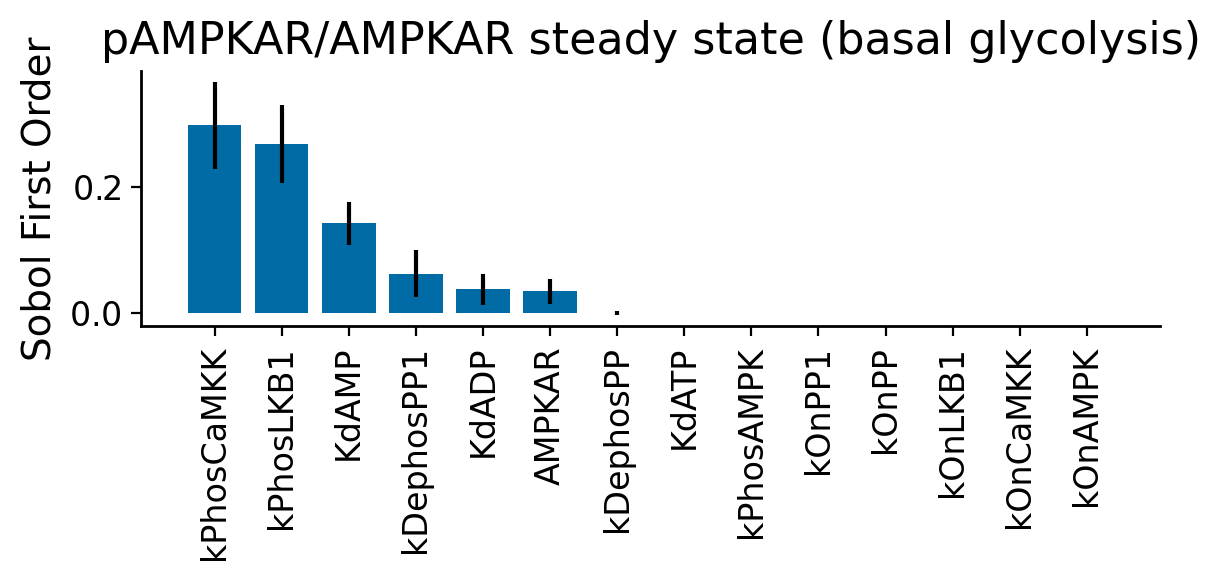

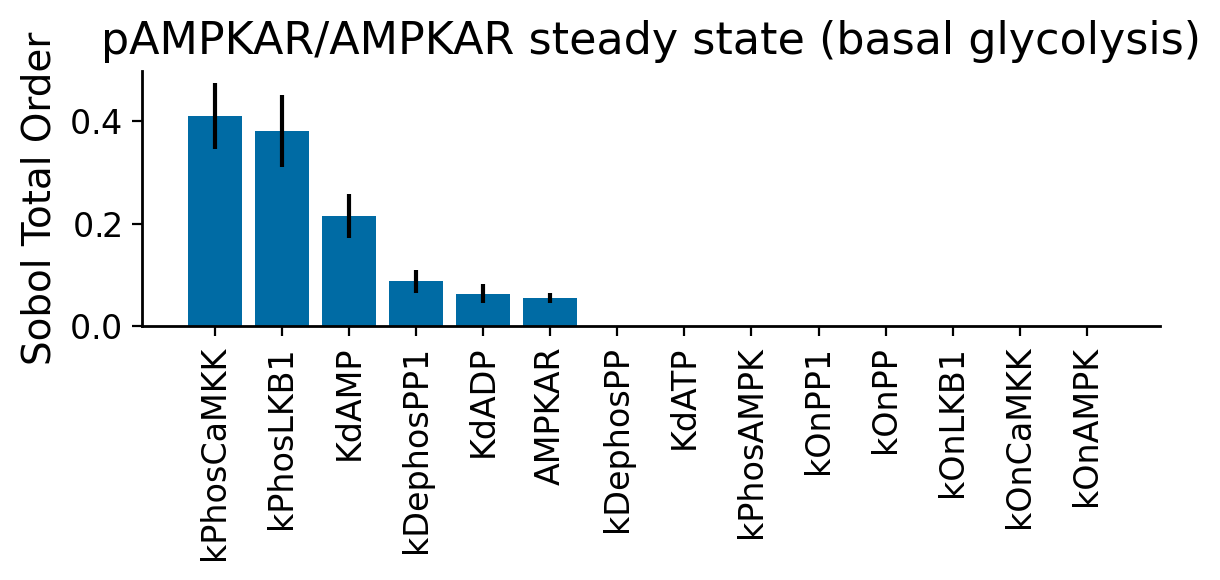

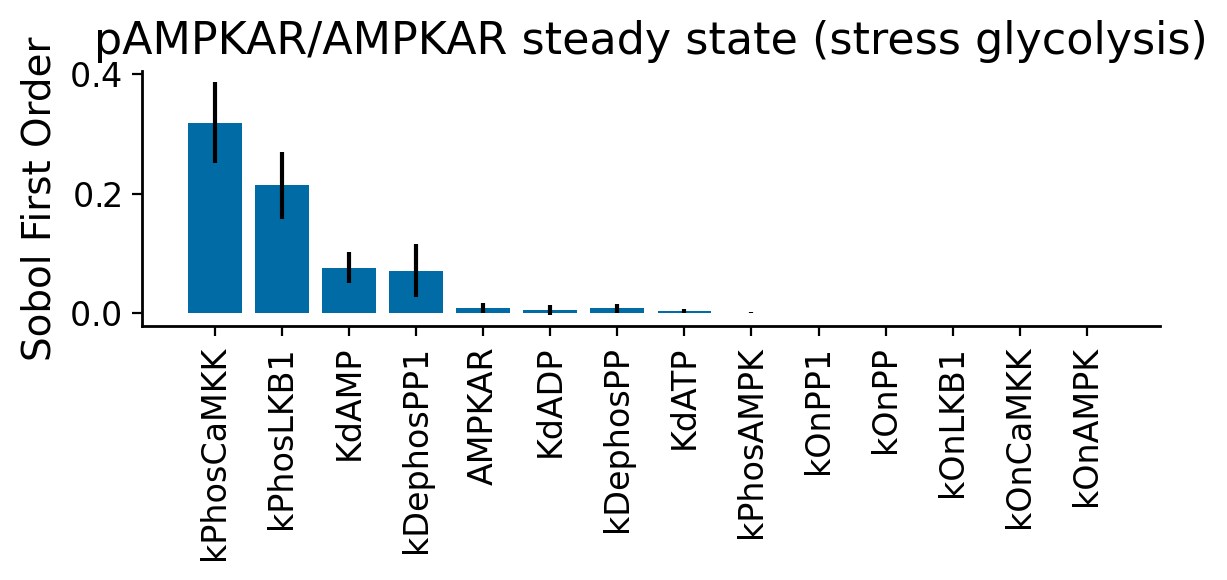

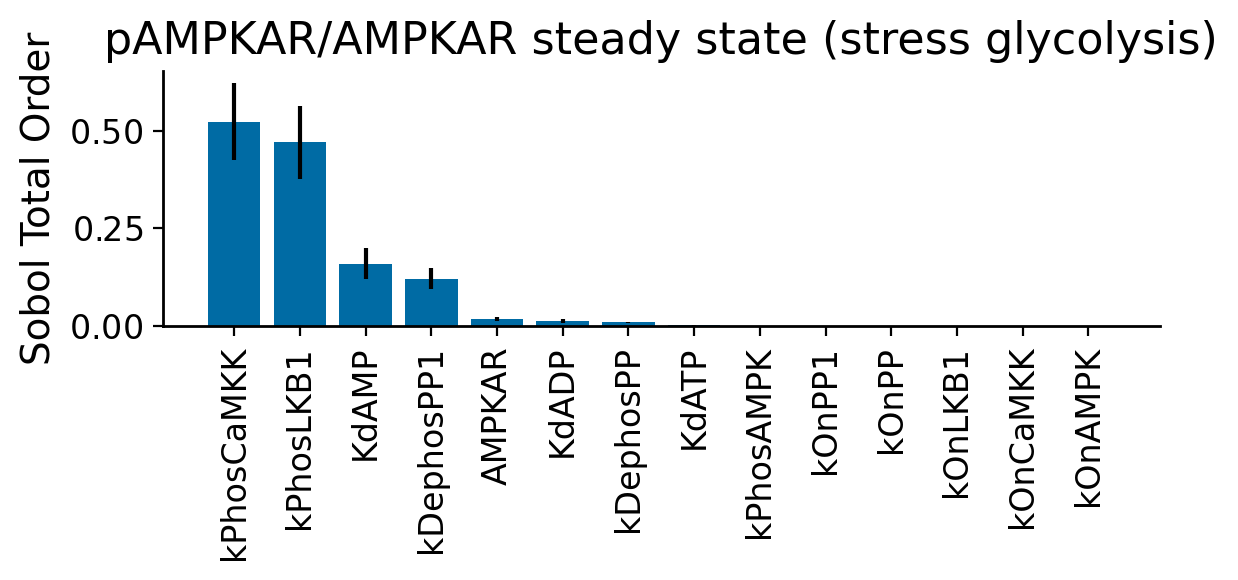

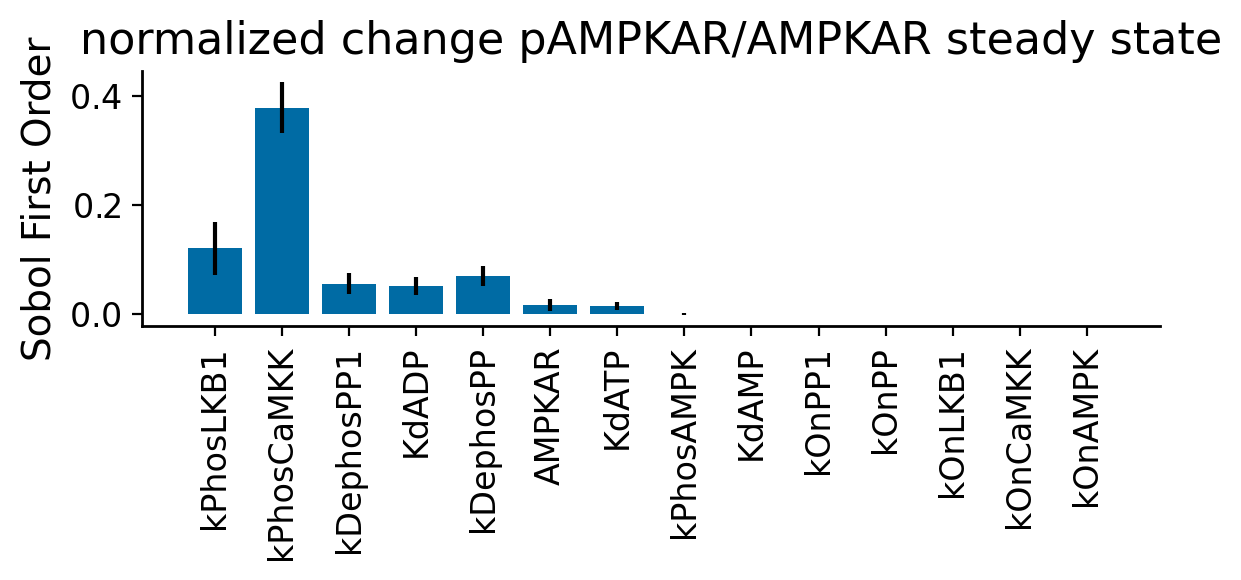

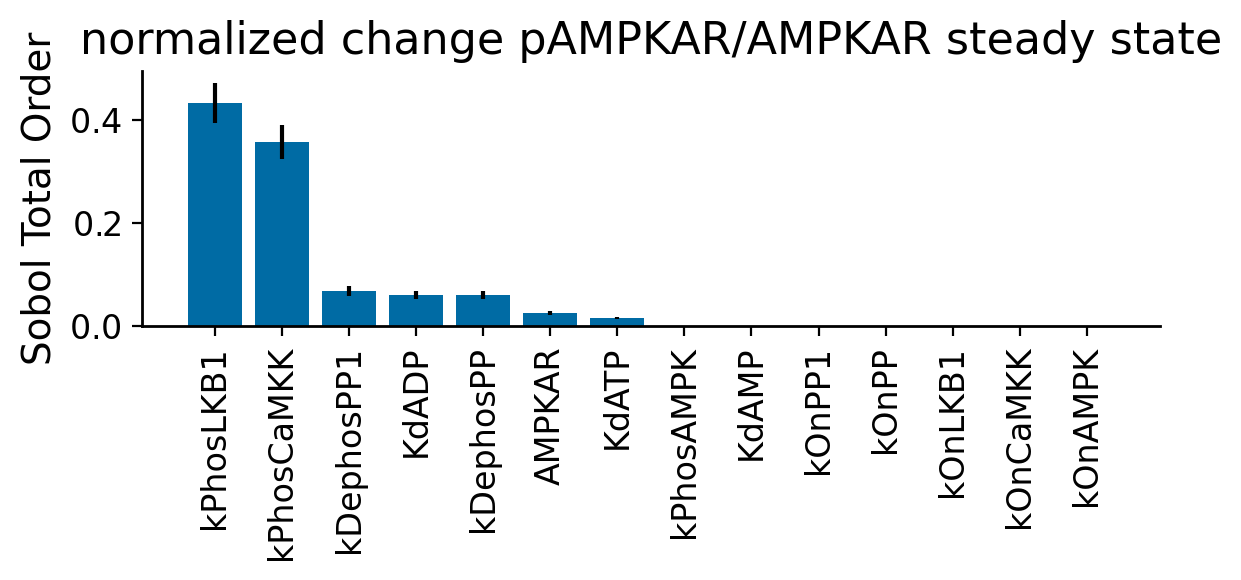

In [50]:
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_ss_basal_sorted['S1'],
        yerr=Si_sobol_ss_basal_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_ss_basal_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)', weight='normal')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/S1_ss_basal.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_ss_basal_sorted['ST'],
        yerr=Si_sobol_ss_basal_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_ss_basal_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)', weight='normal')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/ST_ss_basal.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_ss_stress_sorted['S1'],
        yerr=Si_sobol_ss_stress_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_ss_stress_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('pAMPKAR/AMPKAR steady state (stress glycolysis)', weight='normal')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/S1_ss_stress.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_ss_stress_sorted['ST'],
        yerr=Si_sobol_ss_stress_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_ss_stress_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('pAMPKAR/AMPKAR steady state (stress glycolysis)', weight='normal')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/ST_ss_stress.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_delta_sorted['S1'],
        yerr=Si_sobol_delta_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('normalized change pAMPKAR/AMPKAR steady state', weight='normal')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/S1_change.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_delta_sorted['ST'],
        yerr=Si_sobol_delta_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('normalized change pAMPKAR/AMPKAR steady state', weight='normal')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/ST_change.pdf')
plt.show()

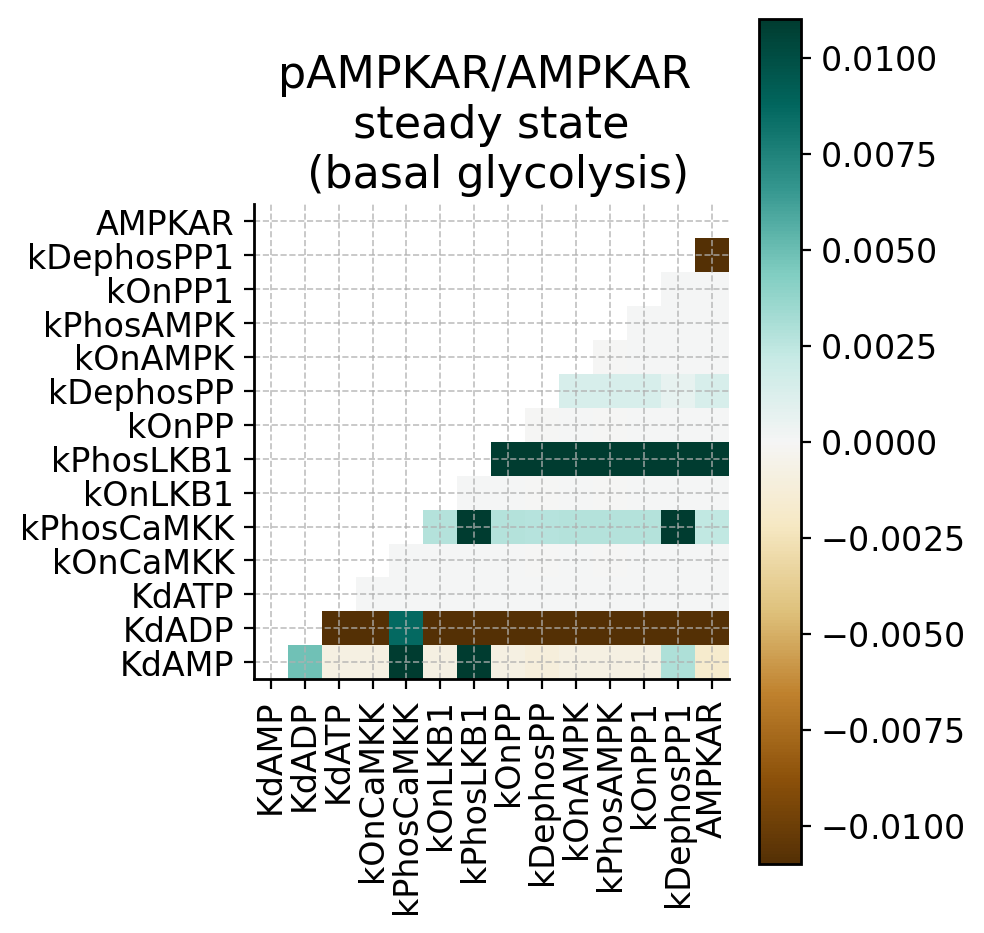

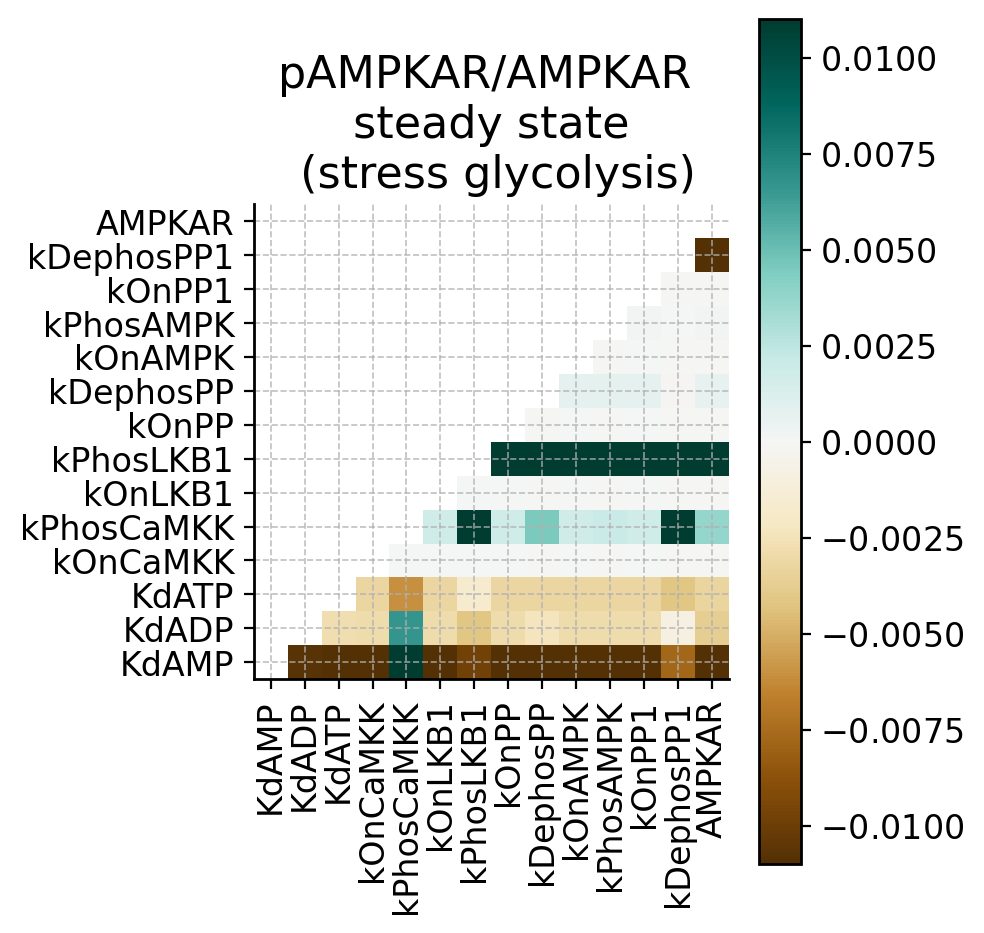

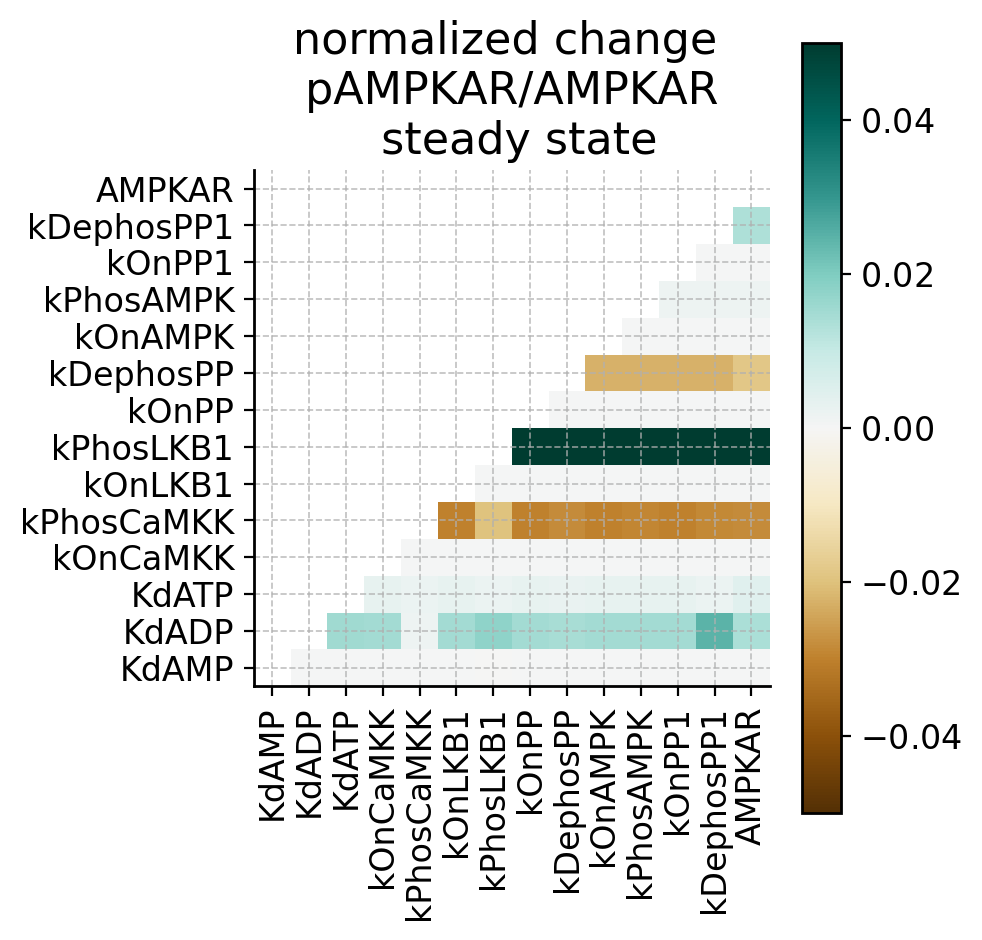

In [52]:
# plot second order
fig, ax = plt.subplots(figsize=(5,5))
cf = ax.pcolormesh(Si_sobol_ss_basal['S2'], vmin=-0.011, vmax=0.011, cmap='BrBG')
fig.colorbar(cf, ax=ax)
ax.set_xticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA, rotation='vertical')
ax.set_yticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title('pAMPKAR/AMPKAR \n steady state \n (basal glycolysis)', weight='normal')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/S2_ss_basal.pdf')

fig, ax = plt.subplots(figsize=(5,5))
cf = ax.pcolormesh(Si_sobol_ss_stress['S2'], vmin=-0.011, vmax=0.011, cmap='BrBG')
fig.colorbar(cf, ax=ax)
ax.set_xticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA, rotation='vertical')
ax.set_yticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title('pAMPKAR/AMPKAR \n steady state \n (stress glycolysis)', weight='normal')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/S2_ss_stress.pdf')

# plot second order
fig, ax = plt.subplots(figsize=(5,5))
cf = ax.pcolormesh(Si_sobol_delta['S2'], vmin=-0.05, vmax=0.05, cmap='BrBG')
fig.colorbar(cf, ax=ax)
ax.set_xticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA, rotation='vertical')
ax.set_yticks(np.arange(0,len(param_names_MA))+0.5, labels=param_names_MA)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title('normalized change \n pAMPKAR/AMPKAR \n steady state', weight='normal')
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/S2_change.pdf')

#### Now for HDMR indices

In [53]:
dtype = [('name', 'U10'), ('Sa', float), ('Sa_conf', float), ('Sb', float), ('Sb_conf', float), ('S', float), ('S_conf', float), ('ST', float), ('ST_conf', float)]
Si_hdmr_ss_basal_sorted = np.array([(name, Sa, Sa_conf, Sb, Sb_conf, S, S_conf, ST, ST_conf) for 
                               name, Sa, Sa_conf, Sb, Sb_conf, S, S_conf, ST, ST_conf in zip(param_names_MA, 
                                                                                             Si_hdmr_ss_basal['Sa'], Si_hdmr_ss_basal['Sa_conf'], 
                                                                                             Si_hdmr_ss_basal['Sb'], Si_hdmr_ss_basal['Sb_conf'],
                                                                                             Si_hdmr_ss_basal['S'], Si_hdmr_ss_basal['S_conf'],
                                                                                             Si_hdmr_ss_basal['ST'], Si_hdmr_ss_basal['ST_conf'])], dtype=dtype)
Si_hdmr_ss_basal_sorted = np.sort(Si_hdmr_ss_basal_sorted, order='S')[::-1]

Si_hdmr_ss_stress_sorted = np.array([(name, Sa, Sa_conf, Sb, Sb_conf, S, S_conf, ST, ST_conf) for 
                               name, Sa, Sa_conf, Sb, Sb_conf, S, S_conf, ST, ST_conf in zip(param_names_MA, 
                                                                                             Si_hdmr_ss_stress['Sa'], Si_hdmr_ss_stress['Sa_conf'], 
                                                                                             Si_hdmr_ss_stress['Sb'], Si_hdmr_ss_stress['Sb_conf'],
                                                                                             Si_hdmr_ss_stress['S'], Si_hdmr_ss_stress['S_conf'],
                                                                                             Si_hdmr_ss_stress['ST'], Si_hdmr_ss_stress['ST_conf'])], dtype=dtype)
Si_hdmr_ss_stress_sorted = np.sort(Si_hdmr_ss_stress_sorted, order='S')[::-1]

Si_hdmr_delta_sorted = np.array([(name, Sa, Sa_conf, Sb, Sb_conf, S, S_conf, ST, ST_conf) for 
                               name, Sa, Sa_conf, Sb, Sb_conf, S, S_conf, ST, ST_conf in zip(param_names_MA, 
                                                                                             Si_hdmr_delta['Sa'], Si_hdmr_delta['Sa_conf'], 
                                                                                             Si_hdmr_delta['Sb'], Si_hdmr_delta['Sb_conf'],
                                                                                             Si_hdmr_delta['S'], Si_hdmr_delta['S_conf'],
                                                                                             Si_hdmr_delta['ST'], Si_hdmr_delta['ST_conf'])], dtype=dtype)
Si_hdmr_delta_sorted = np.sort(Si_hdmr_delta_sorted, order='S')[::-1]

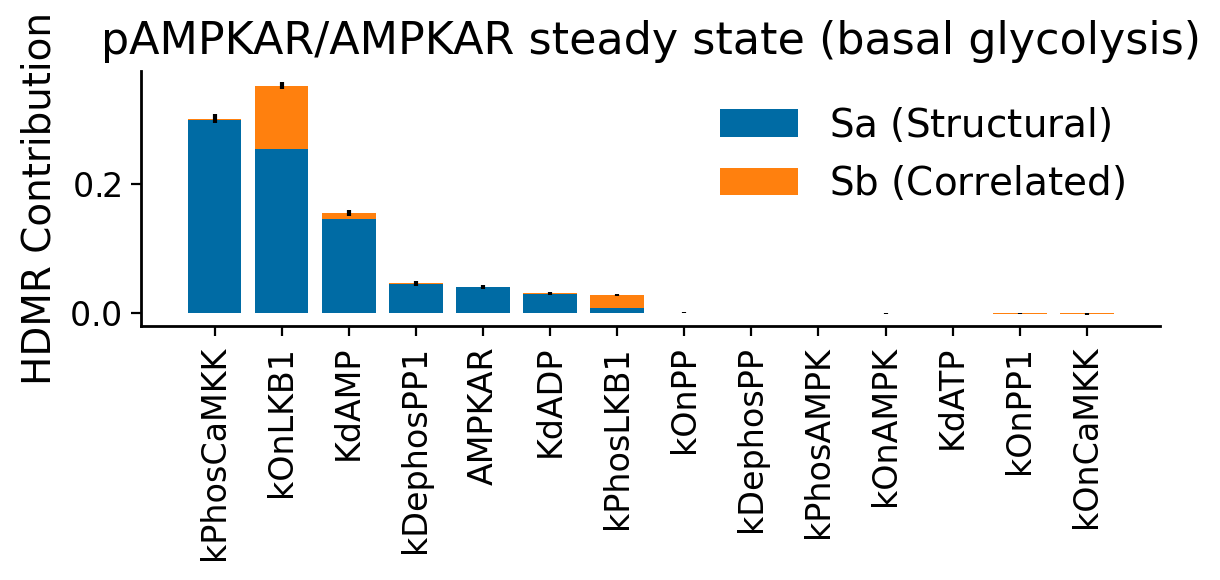

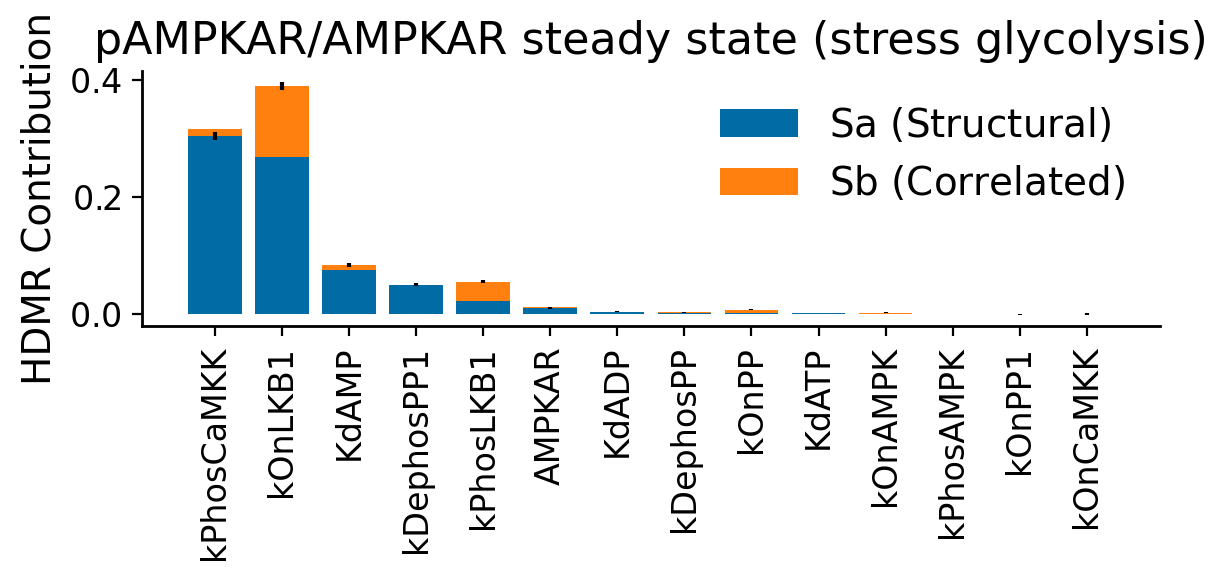

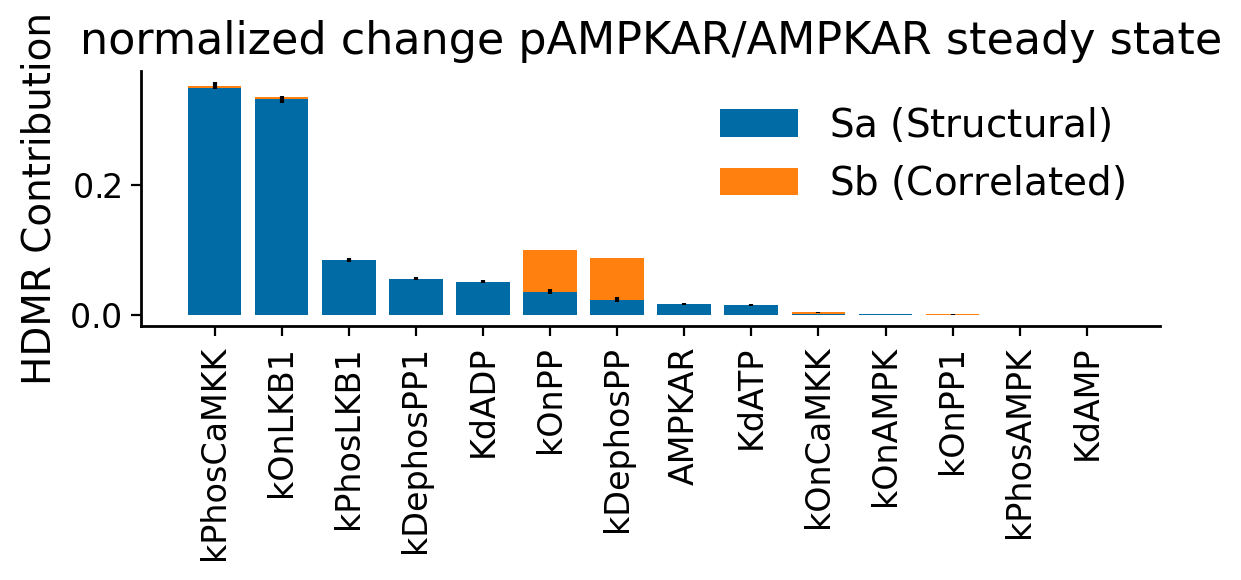

In [55]:
# now visualize the HDMR indices
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,len(Si_hdmr_ss_basal_sorted['Sa'][0:14])), 
       Si_hdmr_ss_basal_sorted['Sa'][0:14],
       bottom=np.zeros(len(Si_hdmr_ss_basal_sorted['Sa'][0:14])), 
       label=r'$Sa$ (Structural)')
ax.bar(np.arange(0,len(Si_hdmr_ss_basal_sorted['Sb'][0:14])), 
       Si_hdmr_ss_basal_sorted['Sb'][0:14],
       bottom=Si_hdmr_ss_basal_sorted['Sa'][0:14], 
       label=r'$Sb$ (Correlated)',
       yerr=Si_hdmr_ss_basal_sorted['S_conf'])
plt.xticks(np.arange(0, len(Si_hdmr_ss_basal_sorted['name'][0:14])), Si_hdmr_ss_basal_sorted['name'][0:14], rotation='vertical')
plt.ylabel('HDMR Contribution')
plt.legend()
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)', weight='normal')
plt.show()
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/hdmr_ss_basal.pdf')

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,len(Si_hdmr_ss_stress_sorted['Sa'][0:14])), 
       Si_hdmr_ss_stress_sorted['Sa'][0:14],
       bottom=np.zeros(len(Si_hdmr_ss_stress_sorted['Sa'][0:14])), 
       label=r'$Sa$ (Structural)')
ax.bar(np.arange(0,len(Si_hdmr_ss_stress_sorted['Sb'][0:14])), 
       Si_hdmr_ss_stress_sorted['Sb'][0:14],
       bottom=Si_hdmr_ss_stress_sorted['Sa'][0:14], 
       label=r'$Sb$ (Correlated)',
       yerr=Si_hdmr_ss_stress_sorted['S_conf'])
plt.xticks(np.arange(0, len(Si_hdmr_ss_stress_sorted['name'][0:14])), Si_hdmr_ss_stress_sorted['name'][0:14], rotation='vertical')
plt.ylabel('HDMR Contribution')
plt.legend()
plt.title('pAMPKAR/AMPKAR steady state (stress glycolysis)', weight='normal')
plt.show()
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/hdmr_ss_stress.pdf')

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,len(Si_hdmr_delta_sorted['Sa'][0:14])), 
       Si_hdmr_delta_sorted['Sa'][0:14],
       bottom=np.zeros(len(Si_hdmr_delta_sorted['Sa'][0:14])), 
       label=r'$Sa$ (Structural)')
ax.bar(np.arange(0,len(Si_hdmr_delta_sorted['Sb'][0:14])), 
       Si_hdmr_delta_sorted['Sb'][0:14],
       bottom=Si_hdmr_delta_sorted['Sa'][0:14], 
       label=r'$Sb$ (Correlated)',
       yerr=Si_hdmr_delta_sorted['S_conf'])
plt.xticks(np.arange(0, len(Si_hdmr_delta_sorted['name'][0:14])), Si_hdmr_delta_sorted['name'][0:14], rotation='vertical')
plt.ylabel('HDMR Contribution')
plt.legend()
plt.title('normalized change pAMPKAR/AMPKAR steady state', weight='normal')
plt.show()
fig.savefig('/scratch/nlinden/AMPK/src/ampk_models/global_sensitivity_analysis/MA_double_mech/hdmr_change.pdf')